- Machine learning algorithms have a somewhat fixed model structure.
    - To achieve good performance, the process of adjusting parameters and training is repeated.
    
- Deep learning requires direct design of the structure.
    - Need to understand various concepts and tools that can be used to achieve good performance

# Loss Curve

- Keras’ fit() method returns an object of the History class.
    - History object: Indicators (loss and accuracy values) calculated during the training process are stored.
    - Use these values ​​to draw a graph to check your training performance

In [2]:
from tensorflow import keras
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

4422102/4422102 [==============================] - 0s 0us/step


In [4]:
scaled_train = x_train / 255
scaled_train, scaled_val, y_train, y_val = train_test_split(scaled_train, y_train,
                                                            test_size = 0.2,
                                                            stratify = y_train,
                                                            random_state = 14)

In [5]:
# function that generates basic model
def model_fn(a_layer = None):
    model = keras.Sequential()
    model.add(keras.layers.Flatten(input_shape = (28, 28)))
    model.add(keras.layers.Dense(100, activation = "relu"))

    if a_layer:
        model.add(a_layer)

    model.add(keras.layers.Dense(10, activation = "softmax"))
    return model

In [6]:
model = model_fn()
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 100)               78500     
                                                                 
 dense_1 (Dense)             (None, 10)                1010      
                                                                 
Total params: 79510 (310.59 KB)
Trainable params: 79510 (310.59 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [7]:
model.compile(loss = "sparse_categorical_crossentropy", metrics = ["accuracy"])

In [8]:
history = model.fit(scaled_train, y_train, epochs = 5)

Epoch 1/5
1500/1500 [==============================] - 10s 6ms/step - loss: 0.5315 - accuracy: 0.8106
Epoch 2/5
1500/1500 [==============================] - 7s 5ms/step - loss: 0.3945 - accuracy: 0.8584
Epoch 3/5
1500/1500 [==============================] - 10s 7ms/step - loss: 0.3571 - accuracy: 0.8712
Epoch 4/5
1500/1500 [==============================] - 4s 3ms/step - loss: 0.3371 - accuracy: 0.8798
Epoch 5/5
1500/1500 [==============================] - 8s 6ms/step - loss: 0.3215 - accuracy: 0.8863


In [9]:
# check history object
print(history.history)

{'loss': [0.531470775604248, 0.3945155739784241, 0.357149213552475, 0.3370797634124756, 0.3215067386627197], 'accuracy': [0.8105833530426025, 0.8583958148956299, 0.8712083101272583, 0.8797916769981384, 0.8862916827201843]}


In [10]:
print(history.history.keys())

dict_keys(['loss', 'accuracy'])


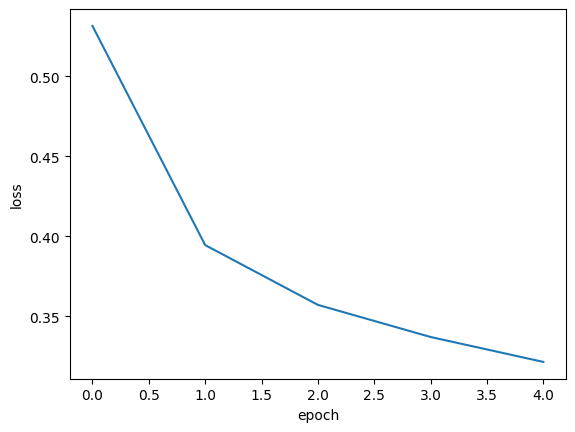

In [11]:
plt.figure()
plt.plot(history.history["loss"])
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

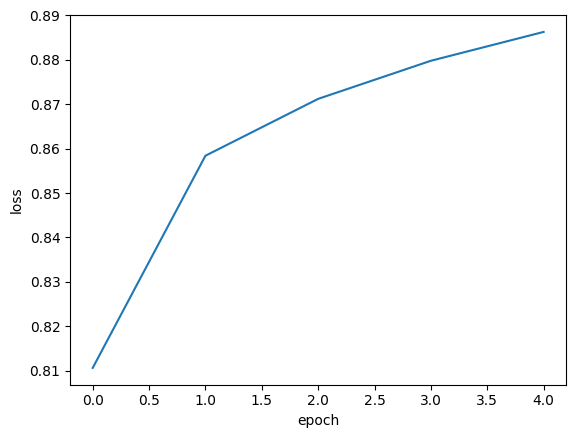

In [12]:
plt.figure()
plt.plot(history.history["accuracy"])
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

In [13]:
# extend to 20 epochs
model = model_fn()
model.compile(loss = "sparse_categorical_crossentropy", metrics = ["accuracy"])

In [14]:
history = model.fit(scaled_train, y_train, epochs = 20)

Epoch 1/20
1500/1500 [==============================] - 9s 5ms/step - loss: 0.5344 - accuracy: 0.8117
Epoch 2/20
1500/1500 [==============================] - 8s 5ms/step - loss: 0.3928 - accuracy: 0.8587
Epoch 3/20
1500/1500 [==============================] - 7s 4ms/step - loss: 0.3564 - accuracy: 0.8728
Epoch 4/20
1500/1500 [==============================] - 8s 5ms/step - loss: 0.3334 - accuracy: 0.8811
Epoch 5/20
1500/1500 [==============================] - 7s 5ms/step - loss: 0.3192 - accuracy: 0.8869
Epoch 6/20
1500/1500 [==============================] - 4s 3ms/step - loss: 0.3078 - accuracy: 0.8897
Epoch 7/20
1500/1500 [==============================] - 4s 3ms/step - loss: 0.2967 - accuracy: 0.8932
Epoch 8/20
1500/1500 [==============================] - 5s 3ms/step - loss: 0.2911 - accuracy: 0.8967
Epoch 9/20
1500/1500 [==============================] - 4s 3ms/step - loss: 0.2832 - accuracy: 0.8999
Epoch 10/20
1500/1500 [==============================] - 4s 3ms/step - loss: 0.274

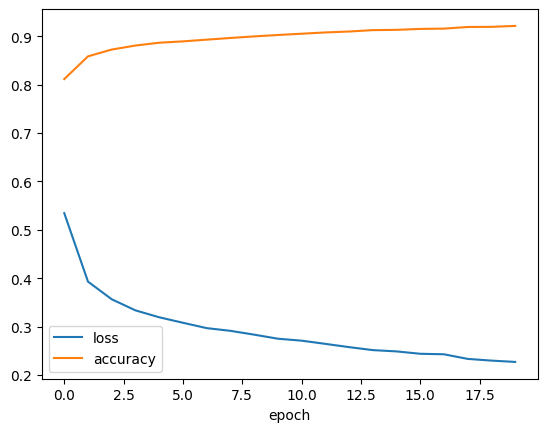

In [15]:
plt.figure()
plt.plot(history.history["loss"], label = "loss")
plt.plot(history.history["accuracy"], label = "accuracy")

plt.legend()
plt.xlabel("epoch")
plt.show()

# Verification Loss

- To identify overfitting and underfitting according to epoch, you must also check the score on the validation set.
- In Keras, verification data can be passed to the fit() method.

In [16]:
model = model_fn()
model.compile(loss = "sparse_categorical_crossentropy", metrics = ["accuracy"])

In [17]:
history = model.fit(scaled_train, y_train, epochs = 20, validation_data = (scaled_val, y_val))

Epoch 1/20
1500/1500 [==============================] - 5s 3ms/step - loss: 0.5390 - accuracy: 0.8105 - val_loss: 0.4458 - val_accuracy: 0.8363
Epoch 2/20
1500/1500 [==============================] - 8s 5ms/step - loss: 0.3998 - accuracy: 0.8552 - val_loss: 0.3785 - val_accuracy: 0.8662
Epoch 3/20
1500/1500 [==============================] - 5s 3ms/step - loss: 0.3588 - accuracy: 0.8712 - val_loss: 0.3539 - val_accuracy: 0.8770
Epoch 4/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.3383 - accuracy: 0.8787 - val_loss: 0.3401 - val_accuracy: 0.8813
Epoch 5/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.3201 - accuracy: 0.8865 - val_loss: 0.3459 - val_accuracy: 0.8758
Epoch 6/20
1500/1500 [==============================] - 5s 3ms/step - loss: 0.3093 - accuracy: 0.8902 - val_loss: 0.3501 - val_accuracy: 0.8781
Epoch 7/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.2993 - accuracy: 0.8941 - val_loss: 0.3539 - val_accuracy:

In [18]:
print(history.history.keys())

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


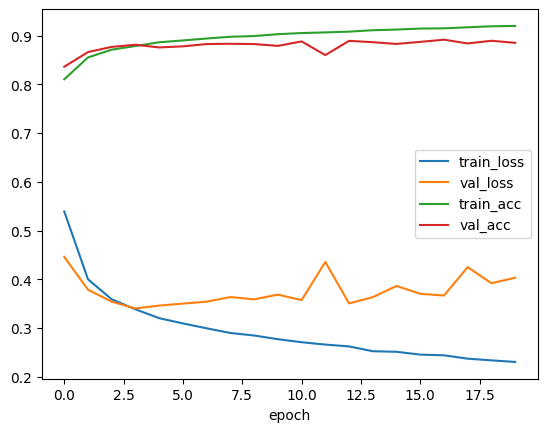

In [19]:
plt.figure()
plt.plot(history.history["loss"], label = "train_loss")
plt.plot(history.history["val_loss"], label = "val_loss")
plt.plot(history.history["accuracy"], label = "train_acc")
plt.plot(history.history["val_accuracy"], label = "val_acc")

plt.legend()
plt.xlabel("epoch")
plt.show()

- Training loss continues to decrease, but validation loss decreases and then increases, creating an overfitting model.
    - It is necessary to delay the increase in verification loss as much as possible.

In [20]:
# Adam Optimizer
model = model_fn()
model.compile(optimizer = "adam", loss = "sparse_categorical_crossentropy",
              metrics = ["accuracy"])

In [21]:
history = model.fit(scaled_train, y_train, epochs = 20, validation_data = (scaled_val, y_val))

Epoch 1/20
1500/1500 [==============================] - 7s 4ms/step - loss: 0.5309 - accuracy: 0.8166 - val_loss: 0.4132 - val_accuracy: 0.8528
Epoch 2/20
1500/1500 [==============================] - 5s 3ms/step - loss: 0.4009 - accuracy: 0.8556 - val_loss: 0.3793 - val_accuracy: 0.8645
Epoch 3/20
1500/1500 [==============================] - 7s 4ms/step - loss: 0.3562 - accuracy: 0.8700 - val_loss: 0.3660 - val_accuracy: 0.8669
Epoch 4/20
1500/1500 [==============================] - 5s 4ms/step - loss: 0.3329 - accuracy: 0.8773 - val_loss: 0.3454 - val_accuracy: 0.8754
Epoch 5/20
1500/1500 [==============================] - 7s 5ms/step - loss: 0.3111 - accuracy: 0.8854 - val_loss: 0.3554 - val_accuracy: 0.8721
Epoch 6/20
1500/1500 [==============================] - 5s 3ms/step - loss: 0.2965 - accuracy: 0.8916 - val_loss: 0.3434 - val_accuracy: 0.8753
Epoch 7/20
1500/1500 [==============================] - 10s 7ms/step - loss: 0.2841 - accuracy: 0.8949 - val_loss: 0.3224 - val_accuracy

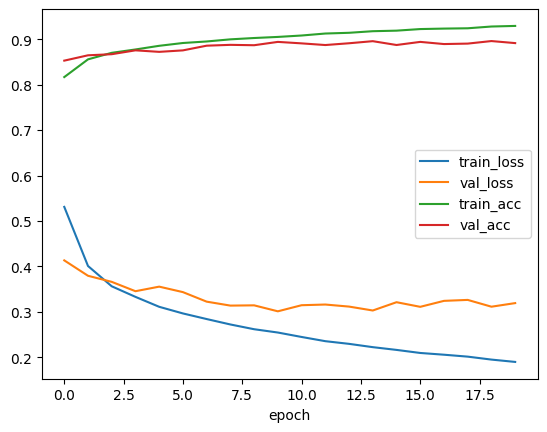

In [22]:
plt.figure()
plt.plot(history.history["loss"], label = "train_loss")
plt.plot(history.history["val_loss"], label = "val_loss")
plt.plot(history.history["accuracy"], label = "train_acc")
plt.plot(history.history["val_accuracy"], label = "val_acc")

plt.legend()
plt.xlabel("epoch")
plt.show()

- The decreasing trend of the verification loss graph continues for a longer period than when using RMSprop, so the Adam optimizer appears to be well suited to this dataset.

# 드롭아웃(dropout)
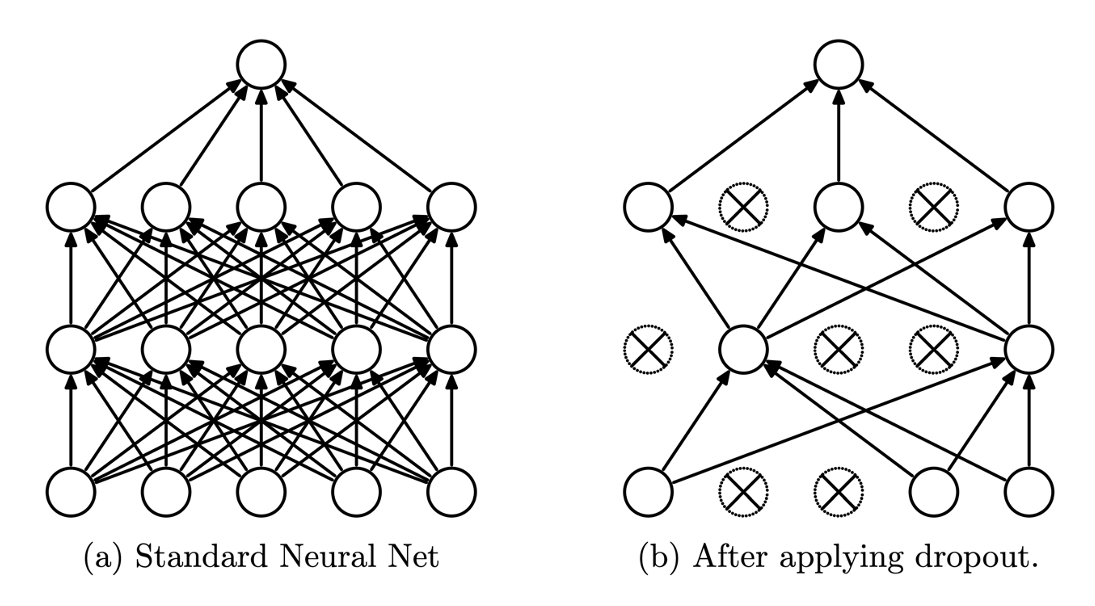

- Intuition: By randomly turning off units, model can't rely on any one feature -> have to spread out weights
- Prevent overfitting by randomly turning off some units in the layer (making the output to 0) during the training process.
    - Reduces over-reliance on specific units
    - Learning takes into account that some units may not have output.
        - Learning in a way that pays sufficient attention to all input values
        
- Dropout is provided by the Dropout class in Keras.
- Place a dropout after a specific layer to randomly set the output of that layer to 0.
- Like Flatten, it is used like a layer, but there are no model parameters to be trained on.

In [23]:
model = model_fn(keras.layers.Dropout(0.3)) # 30% dropout
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_4 (Flatten)         (None, 784)               0         
                                                                 
 dense_8 (Dense)             (None, 100)               78500     
                                                                 
 dropout (Dropout)           (None, 100)               0         
                                                                 
 dense_9 (Dense)             (None, 10)                1010      
                                                                 
Total params: 79510 (310.59 KB)
Trainable params: 79510 (310.59 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


- The size of the input and output of the dropout layer is the same.
    - Sets the output of some units to 0, but does not change the size of the entire output array.
    
- Dropout should not be applied when performing evaluation or prediction after model training is completed.
    - Because correct predictions can only be made using all trained units.
    - Keras does not automatically apply dropout when using a model for evaluation and prediction.

In [24]:
model.compile(optimizer = "adam", loss = "sparse_categorical_crossentropy",
              metrics = ["accuracy"])

In [25]:
history = model.fit(scaled_train, y_train, epochs = 20, validation_data = (scaled_val, y_val))

Epoch 1/20
1500/1500 [==============================] - 7s 4ms/step - loss: 0.5926 - accuracy: 0.7929 - val_loss: 0.4376 - val_accuracy: 0.8393
Epoch 2/20
1500/1500 [==============================] - 5s 3ms/step - loss: 0.4437 - accuracy: 0.8389 - val_loss: 0.3929 - val_accuracy: 0.8523
Epoch 3/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.4067 - accuracy: 0.8514 - val_loss: 0.3545 - val_accuracy: 0.8727
Epoch 4/20
1500/1500 [==============================] - 5s 4ms/step - loss: 0.3820 - accuracy: 0.8618 - val_loss: 0.3445 - val_accuracy: 0.8763
Epoch 5/20
1500/1500 [==============================] - 5s 3ms/step - loss: 0.3710 - accuracy: 0.8634 - val_loss: 0.3244 - val_accuracy: 0.8823
Epoch 6/20
1500/1500 [==============================] - 8s 5ms/step - loss: 0.3540 - accuracy: 0.8709 - val_loss: 0.3254 - val_accuracy: 0.8798
Epoch 7/20
1500/1500 [==============================] - 5s 3ms/step - loss: 0.3447 - accuracy: 0.8714 - val_loss: 0.3302 - val_accuracy:

In [ ]:
plt.figure()
plt.plot(history.history["loss"], label = "train_loss")
plt.plot(history.history["val_loss"], label = "val_loss")
plt.plot(history.history["accuracy"], label = "train_acc")
plt.plot(history.history["val_accuracy"], label = "val_acc")

plt.legend()
plt.xlabel("epoch")
plt.show()

- Compared to previous methods, loss and acc remain relatively constant.

# Save and restore model

- Save the model for reuse later
- Keras models provide a save_weights() method to save model parameters.
- A save() method that provides model structure and model parameters is also provided.

In [27]:
model.save_weights("./model.weights.h5")

In [28]:
model.save("./model-whole.h5")

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Read model parameters only

In [29]:
weights_model = model_fn(keras.layers.Dropout(0.3))

In [30]:
weights_model.load_weights("./model.weights.h5")

- To use the load_weights() method, you must have exactly the same structure as the model saved with save_weights().
- Depending on the TensorFlow version, compile() may need to be executed before using evaluate() due to a bug in load_weights().

In [31]:
val_labels = np.argmax(weights_model.predict(scaled_val), axis=-1)

375/375 [==============================] - 1s 2ms/step


In [32]:
val_labels

array([0, 3, 0, ..., 9, 5, 4])

In [33]:
y_val

array([0, 3, 3, ..., 9, 5, 4], dtype=uint8)

In [34]:
np.mean(val_labels == y_val)

0.8879166666666667

- Keras’ predict() method performs model predictions.
    - Since the dependent variable consists of 10 classes, the probability for each class is returned.
    
- Use the argmax() function to select the largest value from predict() results.
    - Returns the index of the largest value in the array
    - Returns which class has the highest probability value
        - You can see which class was predicted
        
- axis = -1 in the argmax() function selects the maximum value along the last dimension of the array.
    - If axis = 1, select the index of the maximum value of each row along the column.
    - If axis = 0, select the index of the maximum value of each column along the row.
    
- Compares the index selected with argmax() and the target index, and returns 1 if they are the same, and 0 if they are different.
    - Accuracy is obtained by calculating the average of the above values.

## Read entire model

In [37]:
whole_model = keras.models.load_model("./model-whole.h5")

In [38]:
whole_model.evaluate(scaled_val, y_val)

375/375 [==============================] - 1s 2ms/step - loss: 0.3113 - accuracy: 0.8879


[0.31125932931900024, 0.8879166841506958]

# Callback

- An object that allows you to perform some task during the training process
- Used by passing it as a list to the callbacks parameter of the fit() method.

## ModelCheckpoint callback

- Save the model that produces the best validation score while training

In [39]:
checkpoint_cb = keras.callbacks.ModelCheckpoint("./best-model.keras", save_best_only = True)

In [40]:
model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer="adam", loss = "sparse_categorical_crossentropy", metrics = ["accuracy"])

In [41]:
history = model.fit(scaled_train, y_train, epochs=20, validation_data=(scaled_val, y_val), callbacks=[checkpoint_cb])

Epoch 1/20
1500/1500 [==============================] - 6s 3ms/step - loss: 0.5993 - accuracy: 0.7911 - val_loss: 0.4213 - val_accuracy: 0.8498
Epoch 2/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.4427 - accuracy: 0.8415 - val_loss: 0.3820 - val_accuracy: 0.8676
Epoch 3/20
1500/1500 [==============================] - 5s 3ms/step - loss: 0.4052 - accuracy: 0.8541 - val_loss: 0.3527 - val_accuracy: 0.8725
Epoch 4/20
1500/1500 [==============================] - 5s 3ms/step - loss: 0.3888 - accuracy: 0.8602 - val_loss: 0.3454 - val_accuracy: 0.8773
Epoch 5/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.3711 - accuracy: 0.8632 - val_loss: 0.3344 - val_accuracy: 0.8776
Epoch 6/20
1500/1500 [==============================] - 5s 3ms/step - loss: 0.3590 - accuracy: 0.8685 - val_loss: 0.3384 - val_accuracy: 0.8785
Epoch 7/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.3504 - accuracy: 0.8726 - val_loss: 0.3428 - val_accuracy:

- The model with the best val_loss is saved in best-model.keras.

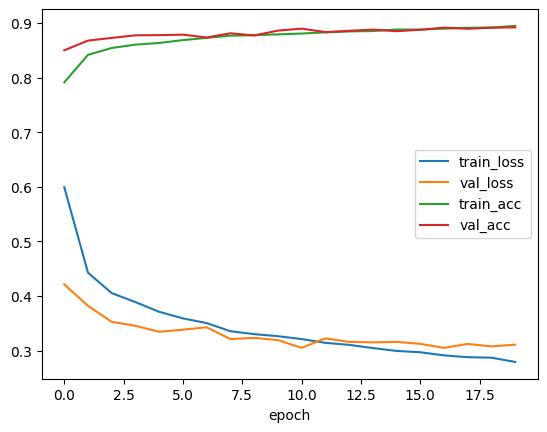

In [42]:
plt.figure()
plt.plot(history.history["loss"], label = "train_loss")
plt.plot(history.history["val_loss"], label = "val_loss")
plt.plot(history.history["accuracy"], label = "train_acc")
plt.plot(history.history["val_accuracy"], label = "val_acc")

plt.legend()
plt.xlabel("epoch")
plt.show()

In [44]:
best_model = keras.models.load_model("./best-model.keras")

In [45]:
best_model.evaluate(scaled_val, y_val)

375/375 [==============================] - 1s 2ms/step - loss: 0.3050 - accuracy: 0.8914


[0.30503734946250916, 0.8914166688919067]

- The ModelCheckpoint callback is convenient because it automatically saves the model with the lowest verification loss value, but it is inconvenient because it still requires training 20 times.

## EarlyStopping callback

- Stopping training before overfitting begins (when the verification score increases) is called early stopping.
- Its role is to limit the number of training epochs, but it is also considered one of the regulation methods because it prevents the model from overfitting.

In [46]:
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)

- patience
    - Number of epochs to watch even if verification score does not improve
    - If patience is 2, training will stop if the verification score does not improve two times in a row.
    
- restore_best_weights
    - Revert to the state of the model with the lowest validation loss

In [47]:
model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [50]:
history = model.fit(scaled_train, y_train, epochs=20, validation_data=(scaled_val, y_val), callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.4311 - accuracy: 0.8446 - val_loss: 0.3741 - val_accuracy: 0.8640
Epoch 2/20
1500/1500 [==============================] - 5s 3ms/step - loss: 0.3992 - accuracy: 0.8547 - val_loss: 0.3817 - val_accuracy: 0.8601
Epoch 3/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.3778 - accuracy: 0.8599 - val_loss: 0.3459 - val_accuracy: 0.8736
Epoch 4/20
1500/1500 [==============================] - 5s 4ms/step - loss: 0.3645 - accuracy: 0.8667 - val_loss: 0.3372 - val_accuracy: 0.8788
Epoch 5/20
1500/1500 [==============================] - 5s 3ms/step - loss: 0.3530 - accuracy: 0.8701 - val_loss: 0.3337 - val_accuracy: 0.8763
Epoch 6/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.3445 - accuracy: 0.8717 - val_loss: 0.3367 - val_accuracy: 0.8742
Epoch 7/20
1500/1500 [==============================] - 5s 3ms/step - loss: 0.3361 - accuracy: 0.8764 - val_loss: 0.3252 - val_accuracy:

In [52]:
# Check at what epoch it stopped
print(early_stopping_cb.stopped_epoch)

12


- Training stops after 13th epoch
    - Since patience is 2, the model from the 11th epoch is the best model.

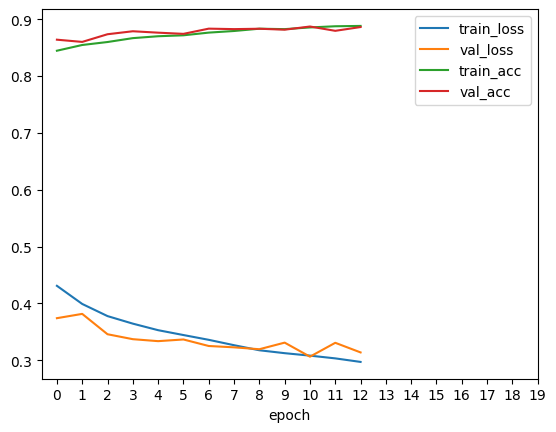

In [53]:
plt.figure()
plt.plot(history.history["loss"], label = "train_loss")
plt.plot(history.history["val_loss"], label = "val_loss")
plt.plot(history.history["accuracy"], label = "train_acc")
plt.plot(history.history["val_accuracy"], label = "val_acc")

plt.xticks(ticks = range(20))
plt.legend()
plt.xlabel("epoch")
plt.show()

In [54]:
model.evaluate(scaled_val, y_val)

375/375 [==============================] - 1s 3ms/step - loss: 0.3064 - accuracy: 0.8872


[0.3064294457435608, 0.8871666789054871]